#1. Project Overview
##Business Problem

Netflix continuously invests in original content. Understanding which genres, countries, and content characteristics drive higher viewership can help improve content investment decisions.

##Objective

Analyze Netflix Originals released between 2016–2025 to identify:

Most popular genres
Highest-viewed titles
Relationship between IMDb ratings and viewership
Top-performing countries
Content trends over time
Tools Used
Python (Pandas, NumPy)


#2. Key Questions

Research Questions


1.   Which Netflix Originals generated the highest viewership?
2.   Does a higher IMDb rating lead to higher viewership?
3. Which genres perform best?
4. Which countries produce the most successful content?
5. How has Netflix content performance evolved from 2016–2025?

In [ ]:
# ==========================================
# NETFLIX ORIGINALS (2016–2025)
# DATA OVERVIEW & DATA CLEANING
# ==========================================

import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

# ==========================================
# 1. LOAD DATA
# ==========================================

df = pd.read_csv(
    "01_Netflix_2016_2025.csv",
    encoding="latin1"
)

# ==========================================
# 2. DATA OVERVIEW
# ==========================================

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

# ==========================================
# 3. STANDARDIZE COLUMN NAMES
# ==========================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_")
)

# ==========================================
# 4. REMOVE DUPLICATES
# ==========================================

df = df.drop_duplicates()

# ==========================================
# 5. CLEAN TEXT COLUMNS
# ==========================================

text_cols = df.select_dtypes(include="object").columns

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# ==========================================
# 6. RELEASE DATE
# ==========================================

df["release_date"] = pd.to_datetime(
    df["release_date"],
    errors="coerce"
)

# ==========================================
# 7. IMDB
# ==========================================

df["imdb"] = pd.to_numeric(
    df["imdb"],
    errors="coerce"
)

# ==========================================
# 8. VIEWERSHIP
# ==========================================

df["viewership_clean"] = (
    df["viewership"]
    .astype(str)
    .str.extract(r'([\d.]+)')
)

df["viewership_clean"] = pd.to_numeric(
    df["viewership_clean"],
    errors="coerce"
)

# ==========================================
# 9. CONTENT TYPE
# ==========================================

df["content_type"] = np.where(
    df["duration"].str.contains(
        "Season",
        case=False,
        na=False
    ),
    "TV Show",
    "Movie"
)

# ==========================================
# 10. MOVIE RUNTIME
# ==========================================

df["runtime_minutes"] = np.where(
    df["content_type"] == "Movie",
    df["duration"].str.extract(r'(\d+)')[0],
    np.nan
)

df["runtime_minutes"] = pd.to_numeric(
    df["runtime_minutes"],
    errors="coerce"
)

# ==========================================
# 11. TV SHOW SEASONS
# ==========================================

df["seasons"] = np.where(
    df["content_type"] == "TV Show",
    df["duration"].str.extract(r'(\d+)')[0],
    np.nan
)

df["seasons"] = pd.to_numeric(
    df["seasons"],
    errors="coerce"
)

# ==========================================
# 12. COUNTRY STANDARDIZATION
# ==========================================

df["country"] = (
    df["country"]
    .replace({
        "USA/UK": "USA & UK",
        "UK/USA": "USA & UK"
    })
)

# ==========================================
# 13. DATE FEATURES
# ==========================================

df["release_year"] = df["release_date"].dt.year

df["release_month"] = (
    df["release_date"]
    .dt.month_name()
)

df["release_quarter"] = (
    df["release_date"]
    .dt.quarter
)

df["release_day"] = (
    df["release_date"]
    .dt.day_name()
)

# ==========================================
# 14. IMDB CATEGORY
# ==========================================

df["imdb_category"] = pd.cut(
    df["imdb"],
    bins=[0, 6, 7, 8, 10],
    labels=[
        "Low",
        "Average",
        "Good",
        "Excellent"
    ]
)

# ==========================================
# 15. POPULARITY CATEGORY
# ==========================================

df["popularity_category"] = pd.qcut(
    df["viewership_clean"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ],
    duplicates="drop"
)

# ==========================================
# 16. GENRE GROUPING
# ==========================================

def genre_group(x):

    x = str(x).lower()

    if "crime" in x:
        return "Crime"

    elif "comedy" in x:
        return "Comedy"

    elif "drama" in x:
        return "Drama"

    elif "thriller" in x:
        return "Thriller"

    elif "sci-fi" in x or "science fiction" in x:
        return "Sci-Fi"

    elif "horror" in x:
        return "Horror"

    elif "animation" in x:
        return "Animation"

    elif "doc" in x:
        return "Documentary"

    elif "fantasy" in x:
        return "Fantasy"

    elif "romance" in x:
        return "Romance"

    elif "action" in x:
        return "Action"

    else:
        return "Other"

df["genre_group"] = df["genre"].apply(genre_group)

# ==========================================
# 17. DATA QUALITY REPORT
# ==========================================

print("\n")
print("="*60)
print("DATA QUALITY REPORT")
print("="*60)

quality_report = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Data Type": df.dtypes.values
})

print(quality_report)

# ==========================================
# 18. SUMMARY STATISTICS
# ==========================================

print("\n")
print("="*60)
print("NUMERICAL SUMMARY")
print("="*60)

print(
    df.select_dtypes(
        include=["int64", "float64"]
    ).describe()
)

# ==========================================
# 19. BUSINESS OVERVIEW
# ==========================================

print("\n")
print("="*60)
print("BUSINESS OVERVIEW")
print("="*60)

print("Total Titles:", len(df))
print("Average IMDb:", round(df["imdb"].mean(), 2))
print("Highest IMDb:", df["imdb"].max())
print("Lowest IMDb:", df["imdb"].min())
print("Countries:", df["country"].nunique())
print("Genres:", df["genre"].nunique())

print("\nContent Type Distribution")
print(df["content_type"].value_counts())

print("\nTop 10 Countries")
print(df["country"].value_counts().head(10))

print("\nTop 10 Genre Groups")
print(df["genre_group"].value_counts())

# ==========================================
# 20. SAVE CLEAN DATA
# ==========================================

df.to_csv(
    "netflix_cleaned.csv",
    index=False
)

print("\n✅ netflix_cleaned.csv saved successfully")

DATASET OVERVIEW
Rows    : 200
Columns : 10

Columns:
['Year', 'Title', 'IMDb', 'Viewership', 'Directors/Creators', 'Lead Actors', 'Release Date', 'Duration', 'Country', 'Genre']

Data Types:
Year                    int64
Title                  object
IMDb                  float64
Viewership             object
Directors/Creators     object
Lead Actors            object
Release Date           object
Duration               object
Country                object
Genre                  object
dtype: object

Missing Values:
Year                  0
Title                 0
IMDb                  0
Viewership            0
Directors/Creators    0
Lead Actors           0
Release Date          0
Duration              0
Country               0
Genre                 0
dtype: int64

Duplicates:
0


DATA QUALITY REPORT
                 Column  Missing Values       Data Type
0                  year               0           int64
1                 title               0          object
2                  

/tmp/ipykernel_18108/1660514618.py:74: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["release_date"] = pd.to_datetime(


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("netflix_cleaned.csv")

print(df.head())

   year                    title  imdb     viewership   directors_creators  \
0  2016  Orange Is the New Black   8.0  23.0M Streams          Jenji Kohan   
1  2016          Stranger Things   8.7  21.7M Streams  The Duffer Brothers   
2  2016             Fuller House   6.7  21.5M Streams        Jeff Franklin   
3  2016       Marvel's Luke Cage   7.3  12.1M Streams    Cheo Hodari Coker   
4  2016       Marvel's Daredevil   8.6  11.6M Streams         Drew Goddard   

                           lead_actors release_date     duration country  \
0          Taylor Schilling, Uzo Aduba   2016-06-17  S4; 730 min     USA   
1     Winona Ryder, Millie Bobby Brown   2016-07-15  S1; 400 min     USA   
2  Candace Cameron Bure, Jodie Sweetin   2016-02-25  S1; 390 min     USA   
3           Mike Colter, Alfre Woodard   2016-09-30  S1; 715 min     USA   
4        Charlie Cox, Deborah Ann Woll   2016-03-18  S2; 650 min     USA   

                genre  viewership_clean content_type  runtime_minutes  \
0

#2. Dataset Summary

In [ ]:
print("="*50)
print("DATASET SUMMARY")
print("="*50)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMovies vs TV Shows")
print(df["content_type"].value_counts())

print("\nTop Countries")
print(df["country"].value_counts().head(10))

print("\nTop Genre Groups")
print(df["genre_group"].value_counts())

DATASET SUMMARY
Rows: 200
Columns: 21

Movies vs TV Shows
content_type
Movie      188
TV Show     12
Name: count, dtype: int64

Top Countries
country
USA            115
UK              23
South Korea     20
Spain            9
Germany          4
USA & UK         4
Canada           3
France           3
USA/France       2
USA/Japan        2
Name: count, dtype: int64

Top Genre Groups
genre_group
Drama          40
Crime          38
Other          28
Comedy         22
Sci-Fi         18
Thriller       16
Horror         10
Animation       8
Documentary     6
Action          5
Fantasy         5
Romance         4
Name: count, dtype: int64


3. IMDb Distribution

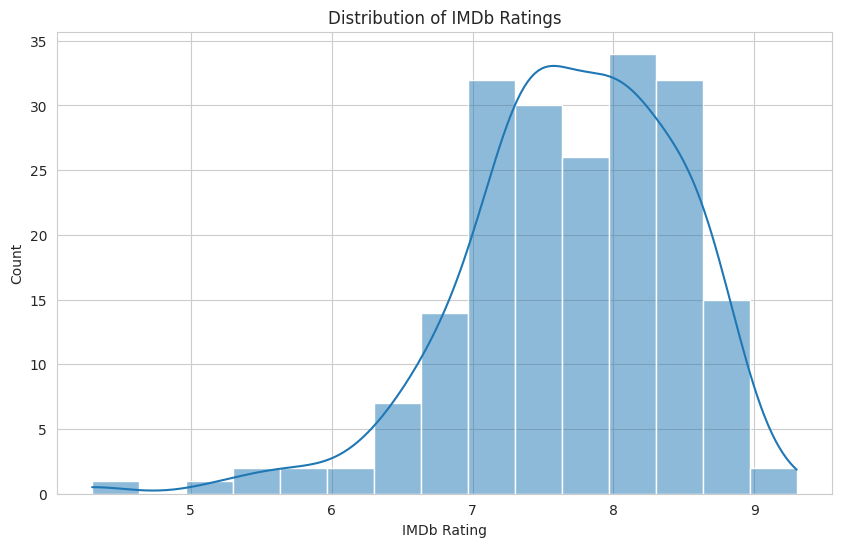

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["imdb"],
    bins=15,
    kde=True
)

plt.title("Distribution of IMDb Ratings")
plt.xlabel("IMDb Rating")
plt.ylabel("Count")

plt.show()

4. IMDb Category Analysis

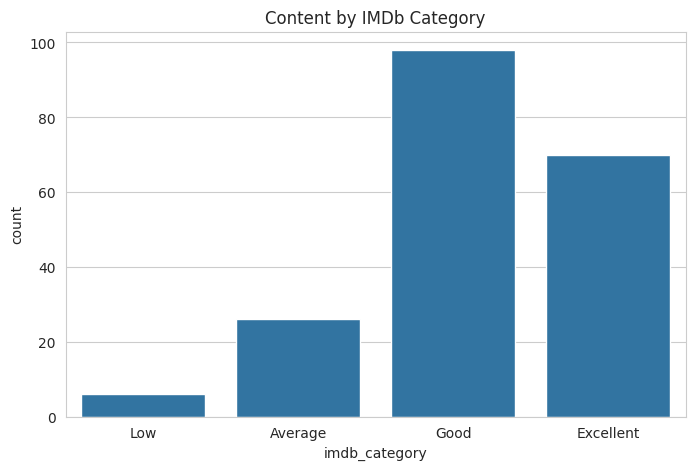

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="imdb_category",
    order=["Low","Average","Good","Excellent"]
)

plt.title("Content by IMDb Category")

plt.show()

5. Top 10 Highest Rated Titles

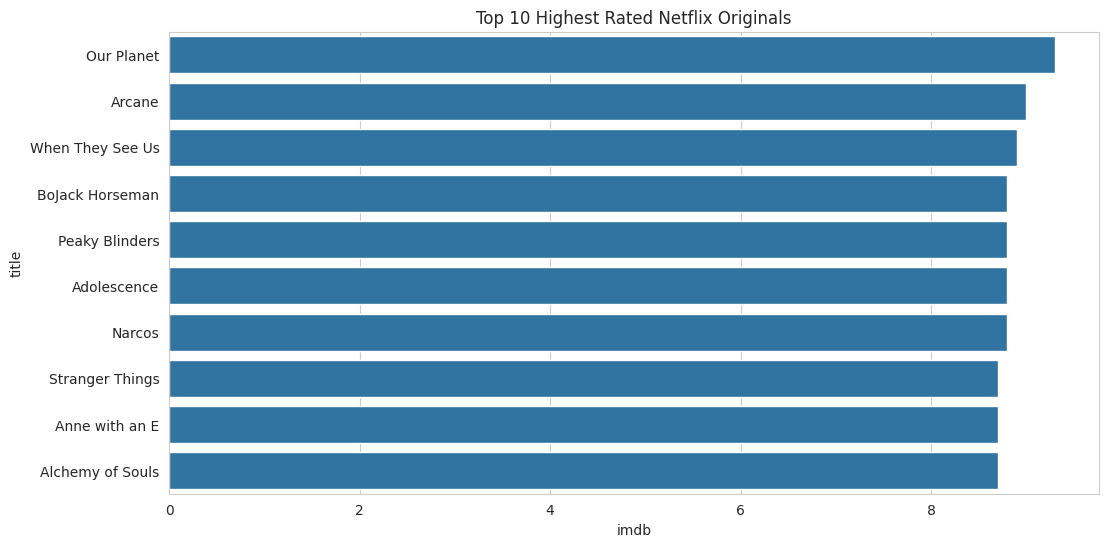

In [ ]:
top_rated = (
    df.sort_values(
        by="imdb",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_rated,
    y="title",
    x="imdb"
)

plt.title("Top 10 Highest Rated Netflix Originals")

plt.show()

6. Top 10 Most Viewed Titles

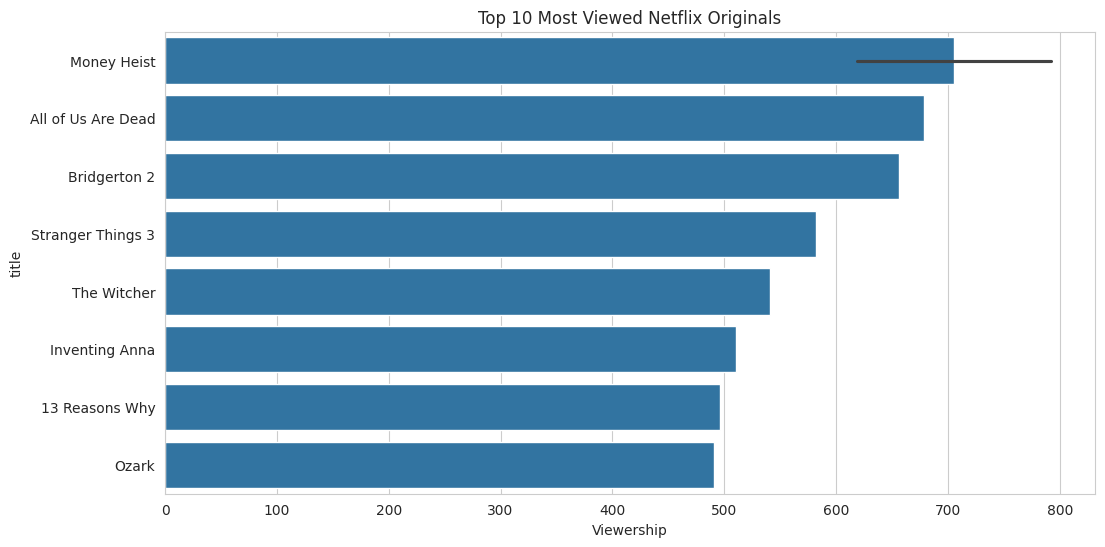

In [ ]:
top_viewed = (
    df.sort_values(
        by="viewership_clean",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_viewed,
    y="title",
    x="viewership_clean"
)

plt.title("Top 10 Most Viewed Netflix Originals")

plt.xlabel("Viewership")

plt.show()

7. IMDb vs Viewership (Correlation)

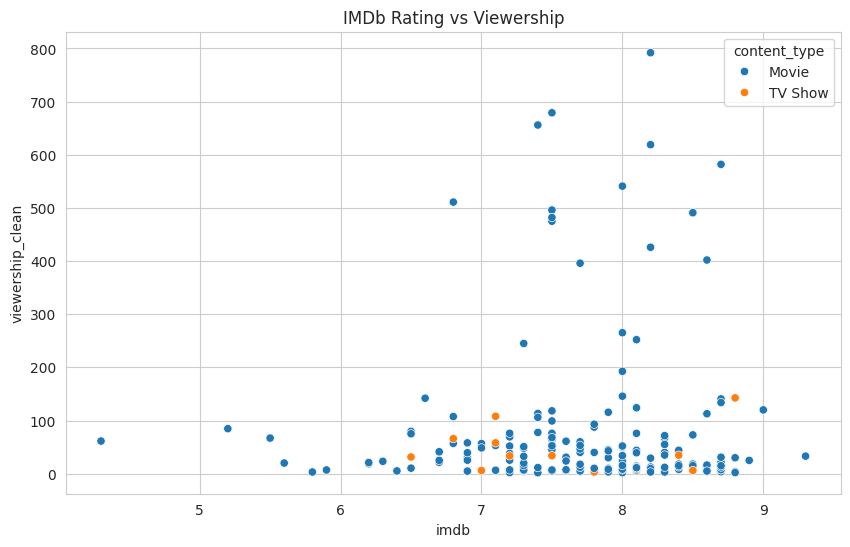

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="imdb",
    y="viewership_clean",
    hue="content_type"
)

plt.title("IMDb Rating vs Viewership")

plt.show()

In [ ]:
correlation = df[
    ["imdb","viewership_clean"]
].corr()

print(correlation)

                      imdb  viewership_clean
imdb              1.000000          0.062795
viewership_clean  0.062795          1.000000


8. Average IMDb by Genre

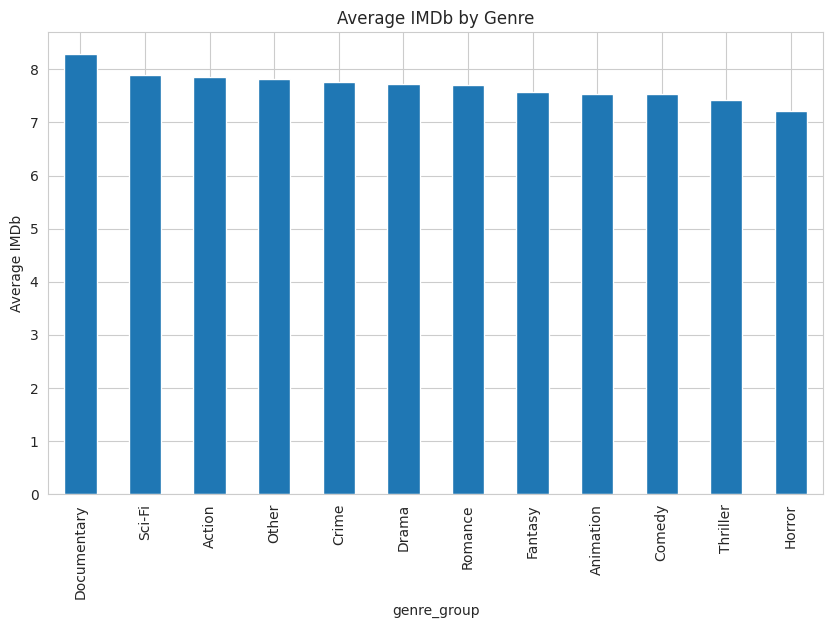

In [ ]:
genre_imdb = (
    df.groupby("genre_group")["imdb"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

genre_imdb.plot(
    kind="bar"
)

plt.title("Average IMDb by Genre")

plt.ylabel("Average IMDb")

plt.show()

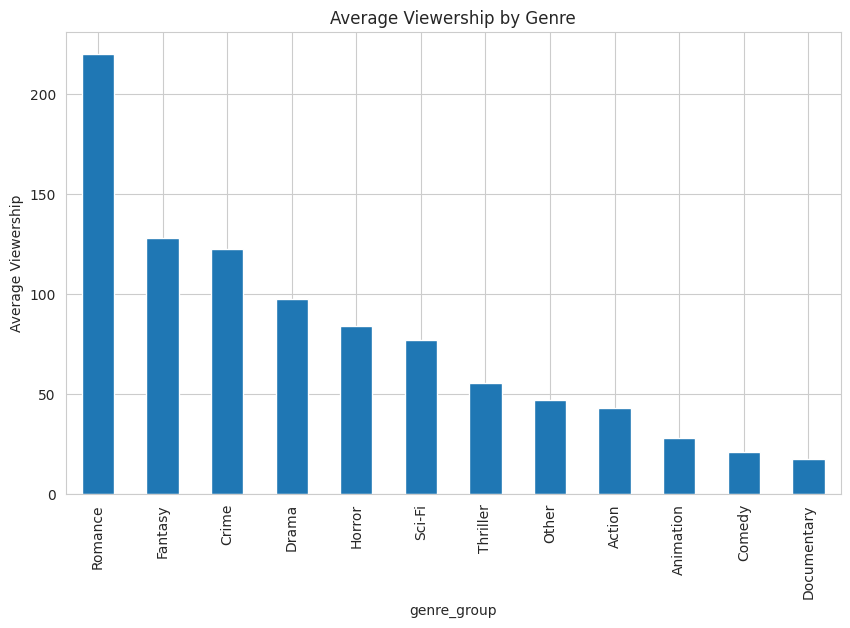

In [ ]:
genre_views = (
    df.groupby("genre_group")["viewership_clean"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

genre_views.plot(
    kind="bar"
)

plt.title("Average Viewership by Genre")

plt.ylabel("Average Viewership")

plt.show()

10. Top Producing Countries

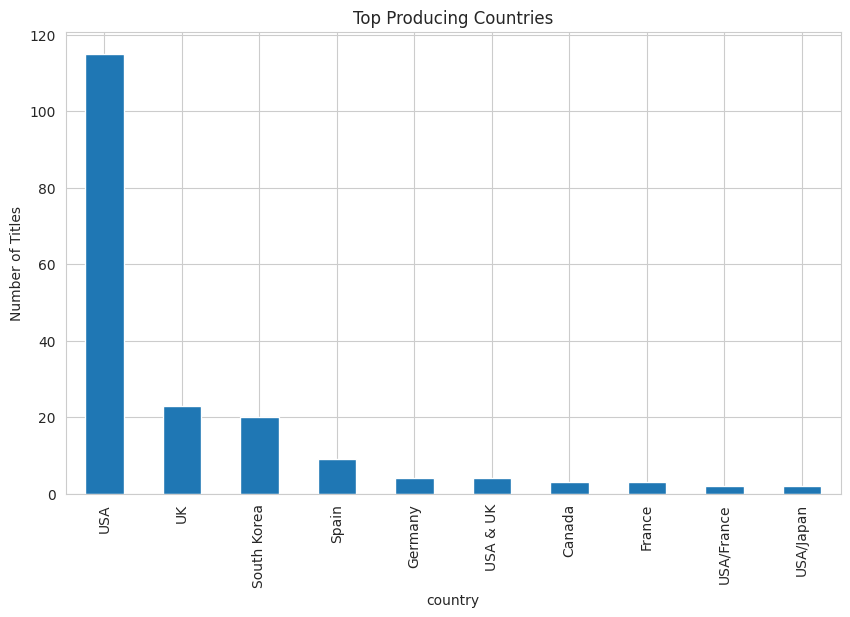

In [ ]:
top_country = (
    df["country"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

top_country.plot(
    kind="bar"
)

plt.title("Top Producing Countries")

plt.ylabel("Number of Titles")

plt.show()

11. Average IMDb by Country

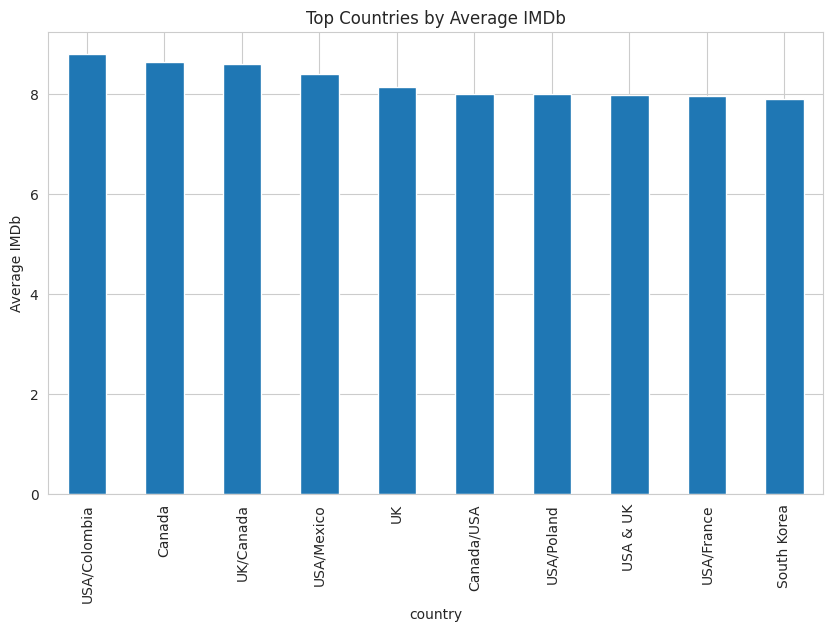

In [ ]:
country_imdb = (
    df.groupby("country")["imdb"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

country_imdb.plot(
    kind="bar"
)

plt.title("Top Countries by Average IMDb")

plt.ylabel("Average IMDb")

plt.show()

12. Release Trend (2016–2025)

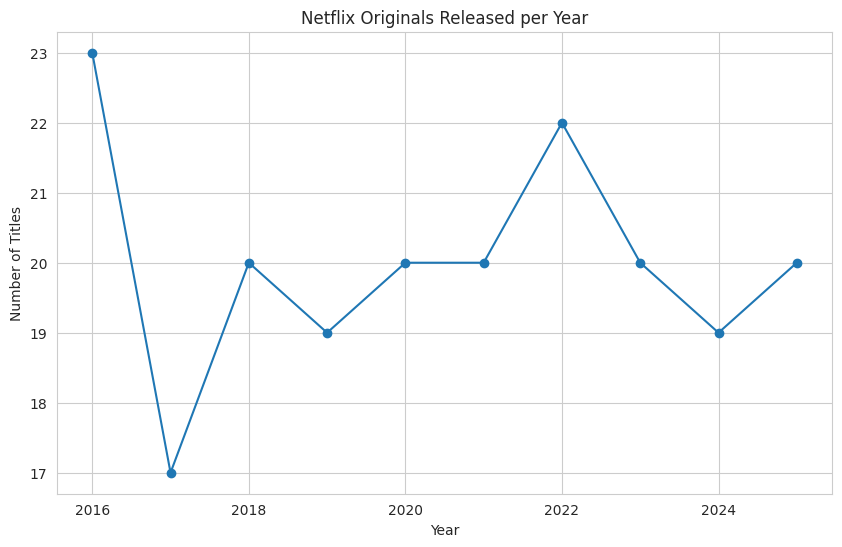

In [ ]:
yearly_titles = (
    df.groupby("release_year")
    .size()
)

plt.figure(figsize=(10,6))

yearly_titles.plot(
    marker="o"
)

plt.title("Netflix Originals Released per Year")

plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

13. Average IMDb Trend

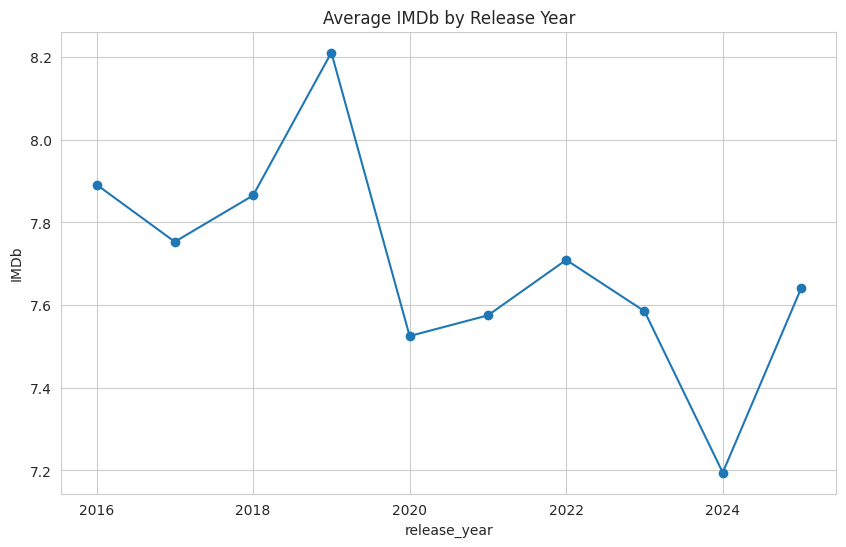

In [ ]:
yearly_imdb = (
    df.groupby("release_year")["imdb"]
    .mean()
)

plt.figure(figsize=(10,6))

yearly_imdb.plot(
    marker="o"
)

plt.title("Average IMDb by Release Year")

plt.ylabel("IMDb")

plt.show()

14. Monthly Release Pattern

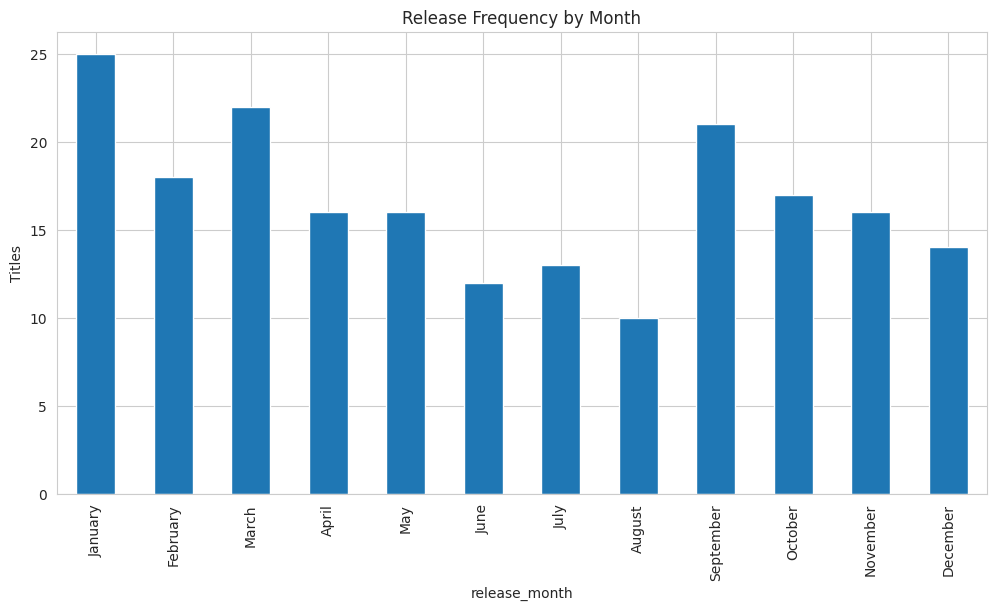

In [ ]:
month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_release = (
    df["release_month"]
    .value_counts()
    .reindex(month_order)
)

plt.figure(figsize=(12,6))

monthly_release.plot(
    kind="bar"
)

plt.title("Release Frequency by Month")

plt.ylabel("Titles")

plt.show()

15. Correlation Heatmap

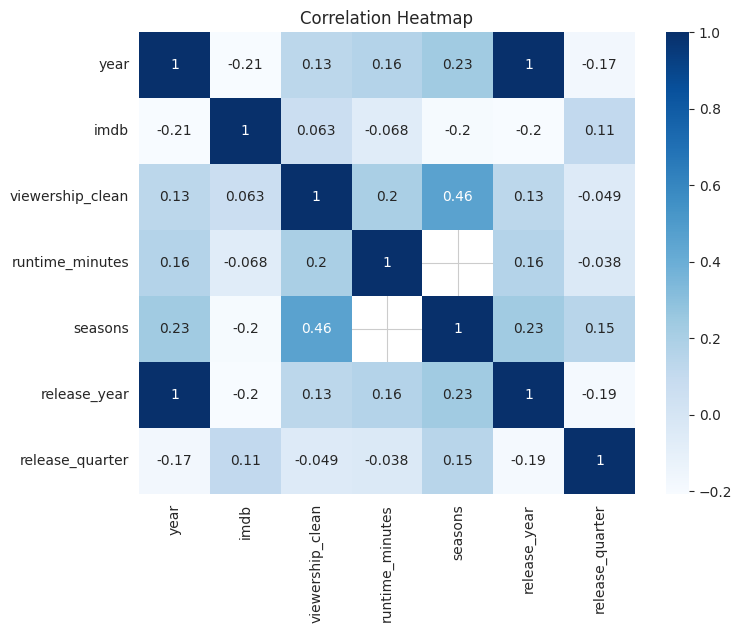

In [ ]:
numeric_df = df.select_dtypes(
    include=["int64","float64"]
)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
print("="*60)
print("KEY INSIGHTS")
print("="*60)

print(
    "Average IMDb:",
    round(df["imdb"].mean(),2)
)

print(
    "Highest Rated Title:"
)

print(
    df.loc[
        df["imdb"].idxmax(),
        ["title","imdb"]
    ]
)

print(
    "\nMost Viewed Title:"
)

print(
    df.loc[
        df["viewership_clean"].idxmax(),
        ["title","viewership_clean"]
    ]
)

print(
    "\nTop Genre:"
)

print(
    df["genre_group"]
    .value_counts()
    .head(1)
)

print(
    "\nTop Country:"
)

print(
    df["country"]
    .value_counts()
    .head(1)
)

KEY INSIGHTS
Average IMDb: 7.7
Highest Rated Title:
title    Our Planet
imdb            9.3
Name: 70, dtype: object

Most Viewed Title:
title               Money Heist
viewership_clean          792.0
Name: 104, dtype: object

Top Genre:
genre_group
Drama    40
Name: count, dtype: int64

Top Country:
country
USA    115
Name: count, dtype: int64
